### Training a Perceptron with Scikit-Learn

Let's use scikit-learn to load the Iris dataset and train a perceptron, similar to what we did in the previous chapter. Here, X is the petal length and petal width of the 150 flower examples and y is the corresponding class labels:

In [1]:
from sklearn import datasets
import numpy as np

iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

print('Class labels:', np.unique(y))

Class labels: [0 1 2]


To evaluate how well a trained model performs on unseen data, we will further split the data into separate training and test datasets:

In [2]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y)

It is important to note that the train_test_split function already shuffles the dataset before splitting, using the random_state internally to generate a pseudo-random number generator to shuffle the dataset. The stratify argument ensures the training and the test subsets have the same proportions of class labels as the input dataset. Let's verify this is the case using bincount: 

In [3]:
print("Labels counts in y:", np.bincount(y))
print("Labels count in y_train:", np.bincount(y_train))
print("Labels count in y_test:", np.bincount(y_test))

Labels counts in y: [50 50 50]
Labels count in y_train: [35 35 35]
Labels count in y_test: [15 15 15]


Now, let's standardize our features using the scikit-learn's preprocessing module:

In [4]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

We can now train a perceptron model. Most models in scikit-learn support multiclass classification by default via one-versus-rest method:

In [6]:
from sklearn.linear_model import Perceptron
ppn = Perceptron(eta0=0.1, random_state=1)
ppn.fit(X_train_std, y_train)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",1


We can now use the predict method to make the predictions for our test dataset.

In [7]:
y_pred = ppn.predict(X_test_std)
print('Misclassified examples: %d' % (y_test != y_pred).sum())

Misclassified examples: 1


We can calculate the accuracy of the perceptron using the scikit-learn's metrics module, or using the score method of the classifier:

In [9]:
from sklearn.metrics import accuracy_score
print("Accuracy: %.3f" % accuracy_score(y_test, y_pred))
print("Accuracy: %.3f" % ppn.score(X_test_std, y_test))

Accuracy: 0.978
Accuracy: 0.978


Let's reuse the plot_decision_functions from the previous chapter to visualize how well the perceptron model separates the classes.

In [12]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_decision_regions(X, y, classifier, test_idx=None, 
                          resolution=0.02):
    
    """
    Plot 2D decision regions for a trained classifier.

    Parameters
    ----------
    X : array-like of shape (n_samples, 2)
        Feature matrix with exactly 2 columns.
    y : array-like of shape (n_samples,)
        Class labels.
    test_idx : array-like of shape (n_test_samples,), optional
        Indices of test samples to highlight.
    classifier : object
        Trained model with a .predict() method.
    resolution : float
        Step size for the background grid.
    """

    # Visual style for each class
    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    unique_classes = np.unique(y)
    cmap = ListedColormap(colors[:len(unique_classes)])

    # Determine plot boundaries from the data
    x_min = X[:, 0].min() - 1
    x_max = X[:, 0].max() + 1
    y_min = X[:, 1].min() - 1
    y_max = X[:, 1].max() + 1

    # Create a dense grid of points covering the whole plot area
    x_values = np.arange(x_min, x_max, resolution)
    y_values = np.arange(y_min, y_max, resolution)
    grid_x, grid_y = np.meshgrid(x_values, y_values)

    # Convert the grid into a list of points:
    # [[x1, y1], [x2, y2], [x3, y3], ...]
    grid_points = np.column_stack([grid_x.ravel(), grid_y.ravel()])

    # Predict a class for every point in the grid
    grid_predictions = classifier.predict(grid_points)

    # Turn the 1D predictions back into the 2D grid shape
    decision_map = grid_predictions.reshape(grid_x.shape)

    # Draw the colored decision regions
    plt.contourf(grid_x, grid_y, decision_map, alpha=0.3, cmap=cmap)
    plt.xlim(grid_x.min(), grid_x.max())
    plt.ylim(grid_y.min(), grid_y.max())

    # Plot the actual data points on top
    for class_index, class_label in enumerate(unique_classes):
        plt.scatter(
            X[y == class_label, 0],
            X[y == class_label, 1],
            alpha=0.8,
            c=colors[class_index],
            marker=markers[class_index],
            label=f"Class {class_label}",
            edgecolor="black"
        )
    
    # Highlight test samples if provided
    if test_idx is not None:
        # Plot test samples with a distinct marker
        plt.scatter(
            X[test_idx, 0],
            X[test_idx, 1],
            c='none',
            edgecolor='black',
            alpha=1.0,
            linewidth=1,
            marker='o',
            s=100,
            label='Test set'
        )

Let's now plot the decision boundary and specify the indices of the examples that we want to mark on the resulting plot:

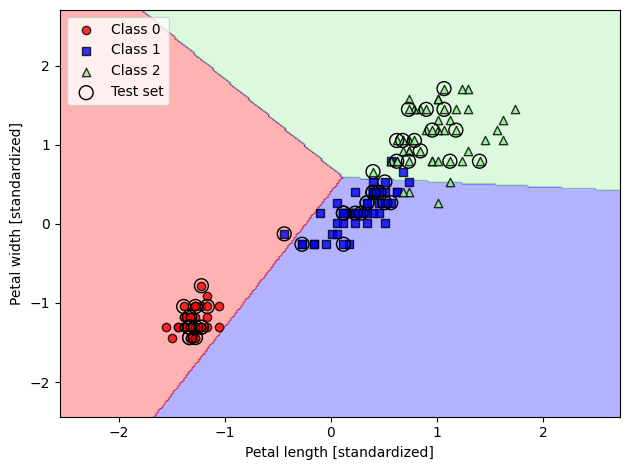

In [13]:
X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((y_train, y_test))
plot_decision_regions(X=X_combined_std,
                      y=y_combined,
                      classifier=ppn,
                      test_idx=range(105, 150))
plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

As we can see, a linear decision boundary cannot perfectly separate the three flower classes. We also mentioned that the perceptron algorithm never converges on datasets that aren't perfectly linearly separable, which is why the use of perceptron algorithm is not typically recommended in practice. 

### Modeling Class Probabilities via Logistic Regression

Let's first plot the sigmoid function to see how it looks:

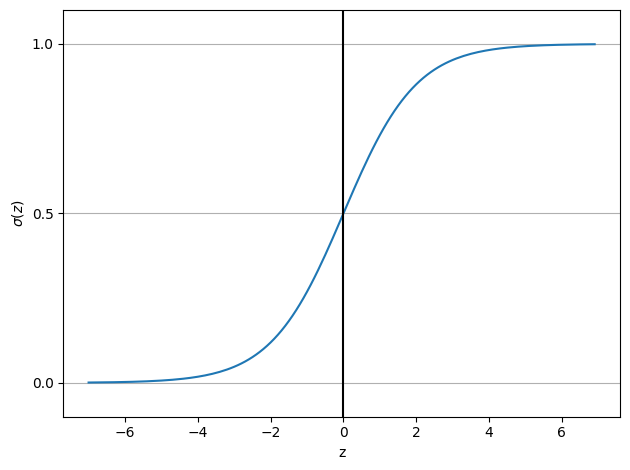

In [17]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

z = np.arange(-7, 7, 0.1)
sigma_z = sigmoid(z)
plt.plot(z, sigma_z)
plt.axvline(0.0, color = 'k')
plt.ylim(-0.1, 1.1)
plt.xlabel('z')
plt.ylabel(r'$\sigma (z)$')
plt.yticks([0.0, 0.5, 1.0])
ax = plt.gca()
ax.yaxis.grid(True)
plt.tight_layout()
plt.show()

To better understand the loss function for logistic regression, let's write a snippet that creates a plot of the loss for a single training example for different values of $\sigma(z)$

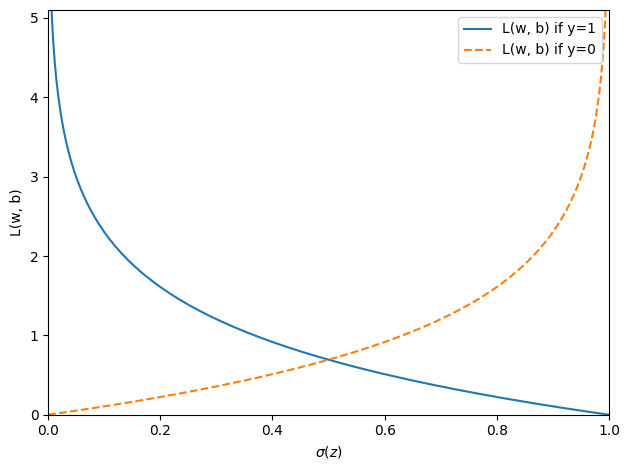

In [19]:
def loss_1(z):
    return -np.log(sigmoid(z))
def loss_0(z):
    return -np.log(1 - sigmoid(z))

z = np.arange(-10, 10, 0.1)
sigma_z = sigmoid(z)
c1 = [loss_1(x) for x in z]
plt.plot(sigma_z, c1, label='L(w, b) if y=1')
c0 = [loss_0(x) for x in z]
plt.plot(sigma_z, c0, linestyle='--', label='L(w, b) if y=0')
plt.ylim(0.0, 5.1)
plt.xlim([0, 1])
plt.xlabel(r'$\sigma (z)$')
plt.ylabel('L(w, b)')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

We can see that the loss approaches 0 if we correctly predict that an example belongs to class 1. Similarly, the loss also approaches 0 if we correctly predict y = 0. If the prediction is wrong, the loss goes toward infinity, which means we penalize the wrong predictions with an increasingly larger loss.

### Implementing Logistic Regression Algorithm

We can write a custom class for Logistic Regression, similar to how we wrote a custom class for Adaline. We just need to replace the loss function with the negative likelihood, and the linear activation function with the sigmoid function:

In [20]:
class LogisticRegressionGD:
    """Gradient descent-based logistic regression classifier.
    
    Parameters
    -----------
    eta : float
      Learning rate (between 0.0 and 1.0)
    n_iter : int
      Passes over the training dataset.
    random_state : int
      Random number generator seed for random weight
      initialization.
    Attributes
    ----------
    w_ : 1d-array
      Weights after training.
    b_ : Scalar
      Bias unit after fitting.
    losses_ : list
      Mean squared error loss function values in each epoch.
    """

    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state
    
    def fit(self, X, y):
        """Fit training data.
        
        Parameters
        ----------
        X : {array-like}, shape = [n_examples, n_features]
          Training vectors, where n_examples is the number of examples and
          n_features is the number of features.
        y : array-like, shape = [n_examples]
          Target values.
        
        Returns
        -------
        self : Instance of LogisticRegressionGD
        """
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.float64(0.)
        self.losses_ = []

        for _ in range(self.n_iter):
            net_input = self.net_input(X)
            output = self.activation(net_input)
            errors = y - output
            self.w_ += self.eta * 2.0 * np.dot(X.T, errors) / X.shape[0]
            self.b_ += self.eta * 2.0 * errors.mean()
            loss = (-y.dot(np.log(output)) - (1 - y).dot(np.log(1 - output))) / X.shape[0]
            self.losses_.append(loss)
        return self

    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)

    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_) + self.b_

    def activation(self, z):
        """Compute logistic sigmoid activation"""
        return 1.0 / (1.0 + np.exp(-np.clip(z, -250, 250)))

Let's see how well our implementation works on separating setosa and versicolor classes:

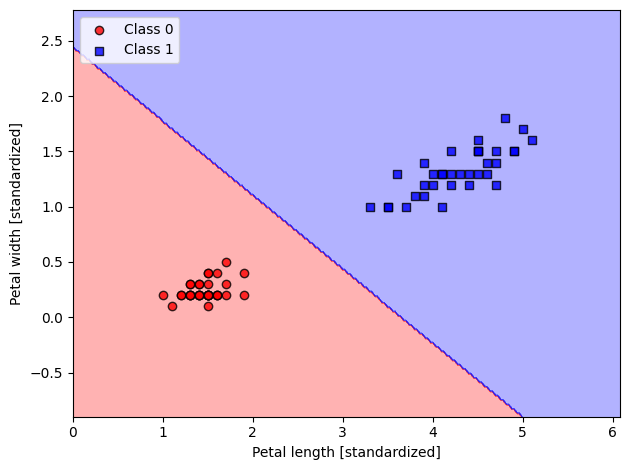

In [21]:
X_train_01_subset = X_train[(y_train == 0) | (y_train == 1)]
y_train_01_subset = y_train[(y_train == 0) | (y_train == 1)]
lrgd = LogisticRegressionGD(eta=0.3,
                             n_iter=1000,
                             random_state=1)
lrgd.fit(X_train_01_subset, y_train_01_subset)
plot_decision_regions(X=X_train_01_subset,
                      y=y_train_01_subset,
                      classifier=lrgd)
plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()